In [1]:
from lbg_forecast.likelihood import Likelihood
import numpy as np
import numpy as np
import lbg_forecast.angular_power as ap
from scipy.optimize import minimize
from scipy.optimize import differential_evolution

path = "./"
lhood_mismatch_int = Likelihood(path, mismatch_int=True)

Initialising likelihood
Initialisation Complete


100%|██████████| 50/50 [03:41<00:00,  4.43s/it]


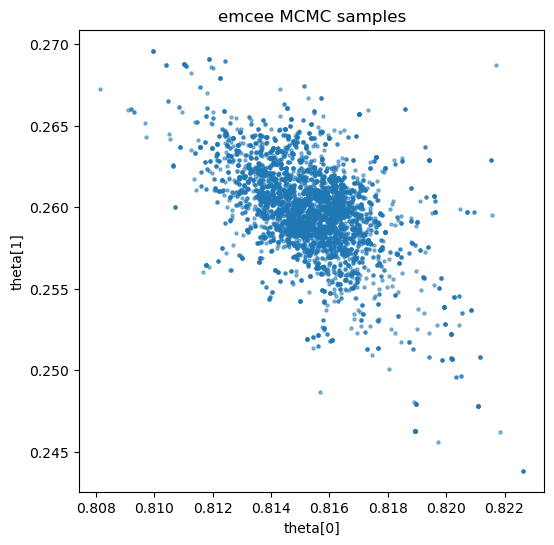

In [31]:
import numpy as np
import emcee
import matplotlib.pyplot as plt

fid_params = np.array([lhood_mismatch_int._cosmo_fid.sigma8, 
                    lhood_mismatch_int._cosmo_fid.Omega_c, lhood_mismatch_int._cosmo_fid.Omega_b,
                    lhood_mismatch_int._cosmo_fid.h, lhood_mismatch_int._cosmo_fid.n_s,
                    lhood_mismatch_int._b_lbg_u, lhood_mismatch_int._b_lbg_g, lhood_mismatch_int._b_lbg_r])

bounds = [(1e-6, 100), 
          (1e-6, 1),
          (1e-6, 1),
          (1e-6, 1),
          (1e-6, 100),
          (1e-6, 100),
          (1e-6, 100),
          (1e-6, 100)] 

def log_lhood(params):

    if((params < 0).any()):
        return -np.inf
    else:
        mu = lhood_mismatch_int.mu_vec_noint(params)
        d = lhood_mismatch_int.cl_mean
        inv_cov = lhood_mismatch_int._inv_C

        value = -0.5*(d - mu)@inv_cov@(d - mu).T

        if np.isnan(value) or np.isinf(value):
            return -np.inf
        else:
            return value

ndim = fid_params.shape[0]
nwalkers = 100
nsteps = 50

# Initialize walkers in a small Gaussian ball around mu
p0 = fid_params + 1e-3 * np.random.randn(nwalkers, ndim)

# Run sampler
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_lhood)
sampler.run_mcmc(p0, nsteps, progress=True)

# Get chain of samples
samples = sampler.get_chain(discard=0, flat=True)

# Plot
plt.figure(figsize=(6,6))
plt.scatter(samples[:,0], samples[:,1], s=5, alpha=0.5)
plt.xlabel("theta[0]")
plt.ylabel("theta[1]")
plt.title("emcee MCMC samples")
plt.show()

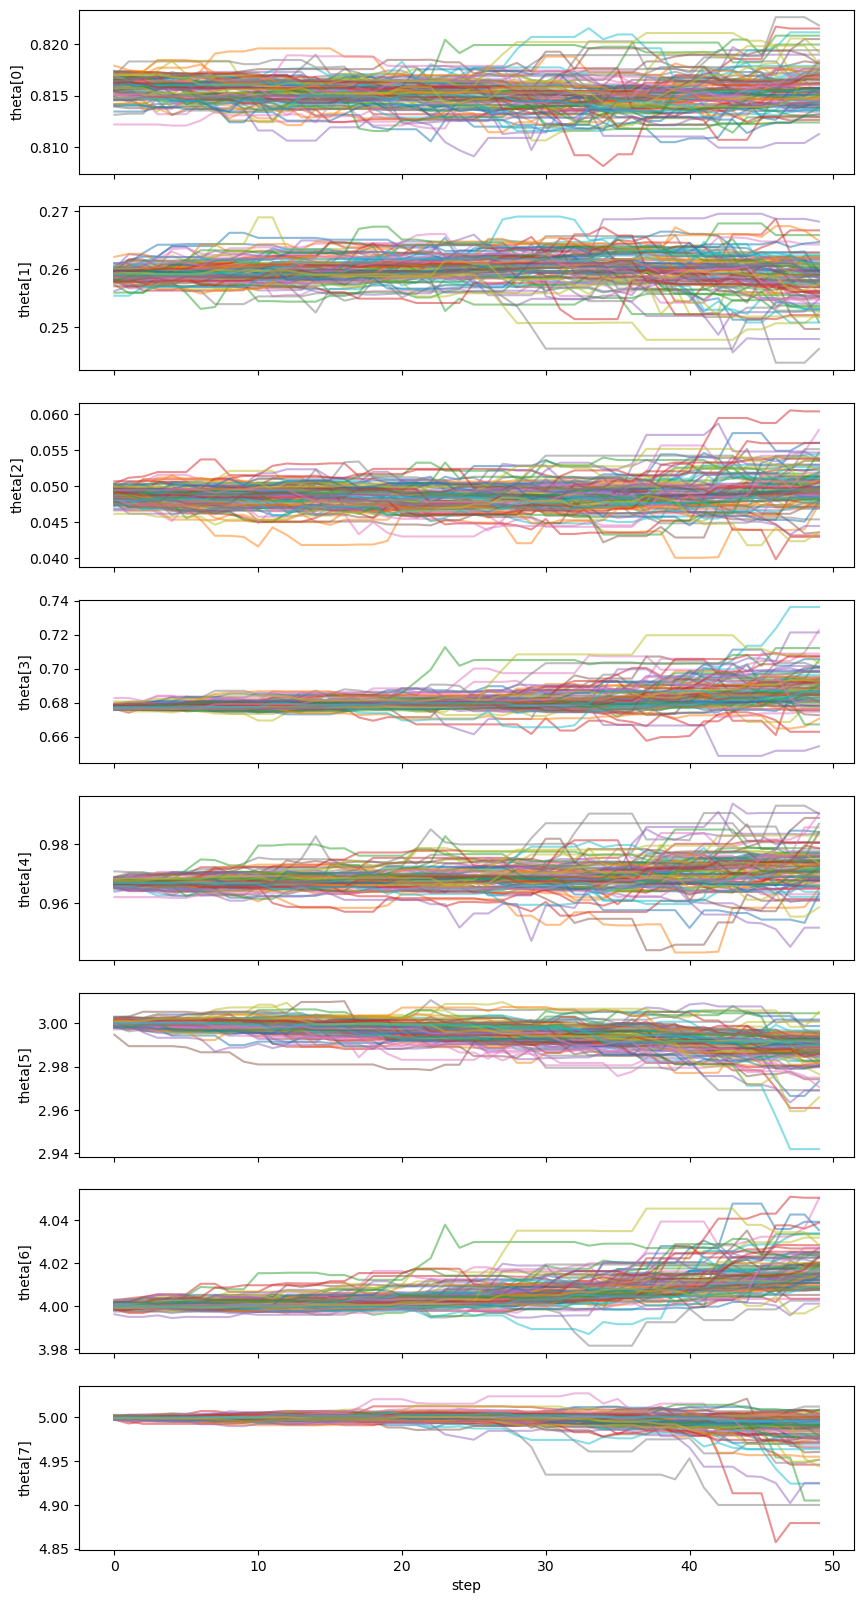

(array([0.8153428 , 0.25976232, 0.04869113, 0.68139815, 0.96875667,
        2.99535187, 4.00587017, 4.99684012]),
 array([0.8159, 0.2589, 0.0486, 0.6774, 0.9667, 3.    , 4.    , 5.    ]))

In [35]:
samples_chain = sampler.get_chain()   # shape (nsteps, nwalkers, ndim)

fig, axes = plt.subplots(ndim, figsize=(10, 20), sharex=True)
for i in range(ndim):
    for w in range(nwalkers):
        axes[i].plot(samples_chain[:, w, i], alpha=0.5)
    axes[i].set_ylabel(f"theta[{i}]")
axes[-1].set_xlabel("step")
plt.show()

np.mean(samples, axis=0), fid_params

In [52]:
from scipy.optimize import minimize

def log_lhood(params):

    if((params < 0).any()):
        return -1e100
    else:
        mu = lhood_mismatch_int.mu_vec_noint(params)
        d = lhood_mismatch_int.cl_mean
        inv_cov = lhood_mismatch_int._inv_C

        value = -0.5*(d - mu)@inv_cov@(d - mu).T

        if np.isnan(value) or np.isinf(value):
            return -1e100
        else:
            return value


res = minimize(lambda x: -log_lhood(x), fid_params, bounds=bounds, method='Nelder-Mead')
print(res.x, fid_params, res.success, log_lhood(fid_params), log_lhood(res.x))
print('%: ', ((res.x - fid_params)/fid_params)*100)


[0.81353726 0.26417063 0.04768997 0.66339203 0.97857789 2.98937759
 4.07569927 4.89744101] [0.8159 0.2589 0.0486 0.6774 0.9667 3.     4.     5.    ] True -4246.2646203335735 -4074.425406489109
%:  [-0.28958675  2.03577732 -1.87248982 -2.06790264  1.22870472 -0.35408048
  1.89248183 -2.05117977]


In [54]:
lhood_mismatch_int.nz_params_mean.shape

(150,)